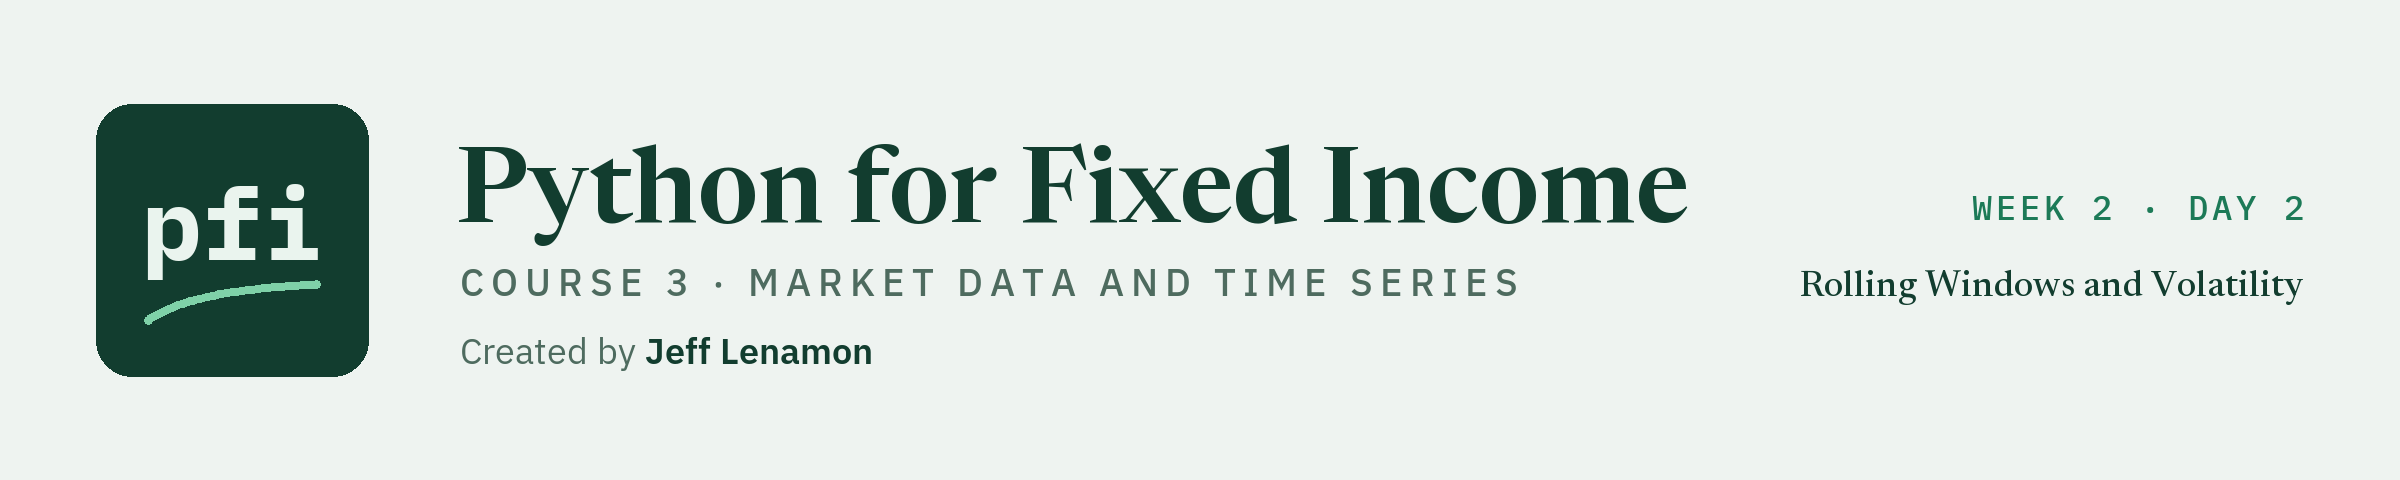

# Rolling Windows and Volatility

Week 2, Day 2. A number on a market screen is only as clear as the window behind it. Today: windows counted in rows, trailing and full, the volatility of daily changes in bp, sample against population, annualising as a labelled choice, and a test that proves no future row leaks into today's number.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course3_market_data/week2/day2/07_rolling_windows_and_volatility.ipynb)

Yesterday you turned yield levels into changes in basis points. Today you summarise those changes over a **window**: a fixed number of recent rows that moves forward one row a day.

The question a desk asks is short: *how much has the 10-year yield been moving lately?* The answer most screens give is a **volatility**: the standard deviation of daily changes over a window. Behind that one number are five choices, and two people who make different ones get different numbers from the same data:

| Choice | This course |
| --- | --- |
| Rows or calendar days? | Rows of the market calendar: 21, 63, and 252 rows, "about one month", "about three months", "about one year" |
| Which rows? | Trailing: the window ending on date t holds t and the rows before it |
| A window that is not full yet? | No value: `NaN` until the window is full |
| Sample or population standard deviation? | Sample (`ddof=1`, Excel `STDEV.S`) |
| Per day or per year? | Per day, unless the name says `_annual` |

Volatility describes how much a series moved over its window. It says nothing about what the series will do next, and this course never reads it as more than that.

Today you will:

1. See what a window in rows and a window in calendar days each hold.
2. Make a trailing window with `min_periods`, and see the `NaN` at the start.
3. Write `rolling_vol_bp`, docstring first, and match Excel's `STDEV.S` filled down a column.
4. Compare sample and population standard deviations, in pandas, NumPy, and Excel.
5. Annualise, and label it.
6. Write `assert_no_lookahead`, the test every window function in this course must pass from today.
7. Draw 21, 63, and 252 rows on one chart.

The data is the Treasury file, the course's snapshot, so no key is needed today and the notebook has no live cell.

Q. Set up today's work folder and copy today's data files into it.

In [1]:
# today's setup: modules, the course data, a fresh work folder, and the constants the live cells use
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# three packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("pytest", "pytest"), ("requests", "requests"), ("dotenv", "python-dotenv")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None
import pytest
import requests

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "treasury_par_yields.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. your own key file: in your my_bondmath folder, outside every repository. Its path is never printed.
ENV_FILE = Path.home() / "projects" / "my_bondmath" / ".env"

# 3. the two constants of the live cells
NO_KEY_MESSAGE = "Live cell skipped: no FRED key was found. Every other cell runs without one."
# ICE BofA and Moody's values stay off the screen unless you set this to True, on your own machine only
SHOW_LICENSED_VALUES = False

# 4. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course3_07_"))
os.chdir(work)

# 5. copy today's data files into the work folder
DATA_FILES = ["treasury_par_yields.csv", "course3_excel_reference.csv", "course3_synthetic_spreads.csv", "course3_fred_format_dgs10.json"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES) or 'none'}")
print(f"pytest {pytest.__version__}, requests {requests.__version__}")

Work folder: pfi_course3_07_ie_8pp3x, in your temp folder
Data files from the data folder of the course repo: treasury_par_yields.csv, course3_excel_reference.csv, course3_synthetic_spreads.csv, course3_fred_format_dgs10.json
pytest 9.1.1, requests 2.34.2


Q. Write `bondmath.py`, the reference copy of the module you finished in Course 2.

It is written into the work folder so that every notebook runs, in Colab too, whether or not you took Course 2. To use your own copy instead, run this line in a new cell after the next one:

```python
shutil.copy(Path.home() / "projects" / "my_bondmath" / "bondmath.py", work)
```

The saved outputs of this notebook always come from the reference copy.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def add_months(d: date, months: int) -> date:
    """Move a date by whole months, keeping the day of the month where the month allows it.

    Units: d is a date, months a whole number (negative moves back).
    Convention: the day is clamped to the length of the new month, so 31 August minus 6 months is
    28 February (29 February in a leap year). Excel: =EDATE(d, months)
    """
    # count months from year 0 so the year and month come out of one division
    month_index = d.year * 12 + (d.month - 1) + months
    year, month_zero_based = divmod(month_index, 12)
    month = month_zero_based + 1
    # the number of days in the new month
    days_in_month = calendar.monthrange(year, month)[1]
    # keep the day, or use the last day of a shorter month
    return date(year, month, min(d.day, days_in_month))


def coupon_dates(settlement: date, maturity: date, frequency: int = 2) -> list[date]:
    """The previous coupon date, then every coupon date left through maturity.

    Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
    months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
    is the last day of its month, every coupon date is the last day of its month (Excel's rule).
    The previous coupon date is the last one on or before settlement.
    So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    # stop on bad input
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # months between coupons
    step_months = 12 // frequency
    # does the bond mature on the last day of a month?
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # coupon k steps back from maturity, computed from maturity itself
        coupon_date = add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: move to the last day of that month
            last_day = calendar.monthrange(coupon_date.year, coupon_date.month)[1]
            coupon_date = date(coupon_date.year, coupon_date.month, last_day)
        dates.append(coupon_date)
        # stop once we reach the previous coupon date
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates


def days_30_360(start: date, end: date) -> int:
    """Days from start to end on the US 30/360 basis, as Excel's COUPDAYBS and YEARFRAC(..., 0) count them.

    Units: dates in, whole days out. Every month counts as 30 days and every year as 360.
    Convention, with D1 the start day and D2 the end day:
    1. If start is the last day of February, D1 = 30.
    2. If start and end are both the last day of February, D2 = 30.
    3. If D1 is 31, D1 = 30.
    4. If D2 is 31 and the start day was 30 or 31, D2 = 30. (Excel looks at the start date's own
       day here, so a start on 28 February and an end on the 31st keeps D2 = 31.)
    Days = 360 x (Y2 - Y1) + 30 x (M2 - M1) + (D2 - D1).
    Excel's DAYS360 uses different February rules and is not the same count.
    """
    d1, d2 = start.day, end.day
    start_is_feb_end = start.month == 2 and start.day == calendar.monthrange(start.year, 2)[1]
    end_is_feb_end = end.month == 2 and end.day == calendar.monthrange(end.year, 2)[1]
    # rule 1: the last day of February counts as the 30th
    if start_is_feb_end:
        d1 = 30
    # rule 2: both dates on the last day of February
    if start_is_feb_end and end_is_feb_end:
        d2 = 30
    # rule 3: a 31st start counts as the 30th
    if start.day == 31:
        d1 = 30
    # rule 4: a 31st end counts as the 30th when the start day was 30 or 31
    if end.day == 31 and start.day >= 30:
        d2 = 30
    return 360 * (end.year - start.year) + 30 * (end.month - start.month) + (d2 - d1)


def coupon_period_days(settlement: date, maturity: date, frequency: int = 2,
                       basis: str = "30/360") -> tuple[int, int, int]:
    """Day counts of the coupon period that holds settlement: (A, E, DSC).

    Units: whole days.
    A is days from the previous coupon to settlement (Excel COUPDAYBS).
    E is days in the coupon period: 360 / frequency under 30/360 (Excel COUPDAYS), and the actual days
    from the previous to the next coupon under ACT/ACT.
    DSC is days from settlement to the next coupon, as Excel's PRICE uses it: E - A under 30/360
    (this can differ from COUPDAYSNC near the end of February), actual days under ACT/ACT.
    """
    # stop on a basis the course does not use (coupon_dates checks frequency and dates)
    if basis not in ("30/360", "ACT/ACT"):
        raise ValueError(f'basis must be "30/360" or "ACT/ACT", not {basis!r}')
    # the previous and next coupon dates
    dates = coupon_dates(settlement, maturity, frequency)
    previous_coupon, next_coupon = dates[0], dates[1]
    if basis == "30/360":
        # 30/360: A by the 30/360 rules, a fixed period length, and DSC as what is left of it
        days_accrued = days_30_360(previous_coupon, settlement)
        days_in_period = 360 // frequency
        days_to_next = days_in_period - days_accrued
    else:
        # ACT/ACT: every count is actual calendar days
        days_accrued = (settlement - previous_coupon).days
        days_in_period = (next_coupon - previous_coupon).days
        days_to_next = (next_coupon - settlement).days
    return days_accrued, days_in_period, days_to_next


def accrued_interest(settlement: date, maturity: date, coupon_pct: float, frequency: int = 2,
                     basis: str = "30/360") -> float:
    """Accrued interest the buyer pays the seller, per 100 of face.

    Units: coupon_pct in percent a year; the result is per 100 of face.
    Convention: coupon_pct / frequency x A / E, with A and E from coupon_period_days.
    Excel (30/360): =100*coupon_pct/100/frequency*COUPDAYBS(...)/COUPDAYS(...)
    """
    # A and E for this settlement
    days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
    # one coupon, times the share of the period that has passed
    return coupon_pct / frequency * days_accrued / days_in_period


def price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
          basis: str = "30/360") -> float:
    """Clean price per 100 of face on any settlement date, as Excel's PRICE.

    Units: coupon_pct and yield_pct in percent a year; the result is a clean price per 100 of face.
    Convention: yield compounded `frequency` times a year. w = DSC / E is the part of a period left
    until the next coupon. Dirty price = sum over the N coupons left of CF_k / (1 + y/f) ** (w + k).
    In the final coupon period (N = 1) Excel uses simple interest: dirty = (100 + CF) / (1 + w x y/f).
    Clean = dirty - accrued interest.
    Excel: =PRICE(settlement, maturity, coupon_pct/100, yield_pct/100, 100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    days_accrued, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    # coupons left, the fraction of a period to the next one, the period yield, and one coupon
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    if coupons_left == 1:
        # final period: simple interest on the last coupon and the face
        dirty = (100 + coupon) / (1 + w * period_yield)
    else:
        dirty = 0.0
        for k in range(coupons_left):
            # the last cash flow also returns the face
            cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
            dirty += cash_flow / (1 + period_yield) ** (w + k)
    # the quote is clean: take off the accrued interest
    return dirty - accrued_interest(settlement, maturity, coupon_pct, frequency, basis)


def dirty_price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                basis: str = "30/360") -> float:
    """Dirty (full, invoice) price per 100 of face: the clean price plus accrued interest.

    Units and convention as price(). Excel: =PRICE(...) + the accrued formula.
    """
    # clean price plus accrued interest
    return (price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
            + accrued_interest(settlement, maturity, coupon_pct, frequency, basis))


def yield_to_maturity(settlement: date, maturity: date, coupon_pct: float, clean_price: float,
                      frequency: int = 2, basis: str = "30/360") -> float:
    """Yield in percent from a clean price on any settlement date, by bisection, as Excel's YIELD x 100.

    Units: coupon_pct in percent a year, clean_price per 100 of face; the result is in percent a year.
    Convention: the yield at which price() equals clean_price. The search runs between -5 and 100
    percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Final coupon period: Excel's YIELD uses a formula instead of a search, with DSR, the days from
    settlement to maturity, counted by days_30_360 under 30/360 (actual days under ACT/ACT):
    yield = ((100 + CF) - dirty) / dirty x frequency x E / DSR. Under 30/360 DSR can differ from the
    E - A that PRICE uses, so in those cases YIELD does not return the yield PRICE was given.
    Excel: =YIELD(settlement, maturity, coupon_pct/100, clean_price, 100, frequency, basis)*100
    """
    # final coupon period: Excel's formula (coupon_dates and coupon_period_days check the inputs)
    if len(coupon_dates(settlement, maturity, frequency)) - 1 == 1:
        days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
        if basis == "30/360":
            days_to_maturity = days_30_360(settlement, maturity)
        else:
            days_to_maturity = (maturity - settlement).days
        coupon = coupon_pct / frequency
        # the dirty price paid, and what comes back at maturity
        paid = clean_price + coupon * days_accrued / days_in_period
        received = 100 + coupon
        # the simple return over the days left, made annual, in percent
        return (received - paid) / paid * frequency * days_in_period / days_to_maturity * 100
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price(settlement, maturity, coupon_pct, low_pct, frequency, basis)
    lowest_price = price(settlement, maturity, coupon_pct, high_pct, frequency, basis)
    if not lowest_price <= clean_price <= highest_price:
        raise ValueError(f"price {clean_price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price(settlement, maturity, coupon_pct, mid_pct, frequency, basis) > clean_price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def macaulay_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Macaulay duration in years: the present-value weighted average time of the cash flows.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: t_k = (w + k) / frequency years, PV_k = CF_k / (1 + y/f) ** (w + k), and
    duration = sum of t_k x PV_k / sum of PV_k. In the final period this is DSC / E / frequency.
    Excel: =DURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, weighted_time = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow, its time in years, and its present value
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        pv = cash_flow / (1 + period_yield) ** (w + k)
        total_pv += pv
        weighted_time += time_years * pv
    # the weighted average time
    return weighted_time / total_pv


def modified_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Modified duration in years: the percent price change for a 1-point (100 bp) change in yield.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: Macaulay duration / (1 + y / frequency), with y = yield_pct / 100.
    Excel: =MDURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # divide Macaulay duration by one plus the period yield
    period_yield = yield_pct / 100 / frequency
    return macaulay_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis) / (1 + period_yield)


def dv01(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
         basis: str = "30/360") -> float:
    """DV01: price points per 100 of face for a 1 basis point fall in yield, positive for a long position.

    Units: coupon_pct and yield_pct in percent a year; the result is in price points per 100 of face per bp.
    Convention: modified duration x dirty price x 0.0001. Position DV01 in dollars = dv01 x par / 100.
    Excel: =MDURATION(...)*(PRICE(...)+accrued)/10000
    """
    # modified duration times the dirty price, for one basis point (0.0001 as a decimal)
    duration_years = modified_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    return duration_years * full_price * 0.0001


def convexity(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
              basis: str = "30/360") -> float:
    """Convexity in years squared, unscaled (not divided by 100 or by 2).

    Units: coupon_pct and yield_pct in percent a year; the result is in years squared.
    Convention: (1 / P) x sum of CF_k x t_k x (t_k + 1/f) / (1 + y/f) ** (f t_k + 2), where
    t_k = (w + k) / f and P is the sum of the discounted cash flows. Price change estimate:
    dP / P = -D_mod x dy + 0.5 x convexity x dy ** 2, with dy in decimal.
    Excel has no convexity function; the check is a central difference on three PRICE cells.
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, curvature = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow and its time in years
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        # its present value, and its term in the convexity sum
        total_pv += cash_flow / (1 + period_yield) ** (w + k)
        curvature += (cash_flow * time_years * (time_years + 1 / frequency)
                      / (1 + period_yield) ** (frequency * time_years + 2))
    # divide by the price
    return curvature / total_pv


def interpolate_yield(tenor_years: float, curve_tenors: list[float], curve_yields_pct: list[float]) -> float:
    """Yield at any tenor by straight-line interpolation on a curve, flat beyond its ends.

    Units: tenors in years, yields in percent; the result is in percent.
    Convention: linear in yield against tenor between the two curve points around tenor_years. Below
    the first tenor the first yield is used, above the last tenor the last yield (as numpy.interp).
    Raises ValueError if the lists differ in length, are empty, or the tenors do not ascend.
    """
    # stop on a curve the function cannot read
    if len(curve_tenors) != len(curve_yields_pct) or len(curve_tenors) == 0:
        raise ValueError("curve_tenors and curve_yields_pct must be non-empty and the same length")
    for i in range(1, len(curve_tenors)):
        if curve_tenors[i] <= curve_tenors[i - 1]:
            raise ValueError(f"curve tenors must ascend: {curve_tenors[i - 1]} then {curve_tenors[i]}")
    # flat beyond the ends
    if tenor_years <= curve_tenors[0]:
        return curve_yields_pct[0]
    if tenor_years >= curve_tenors[-1]:
        return curve_yields_pct[-1]
    # find the two tenors around tenor_years
    i = 1
    while curve_tenors[i] < tenor_years:
        i += 1
    left_tenor, right_tenor = curve_tenors[i - 1], curve_tenors[i]
    left_yield, right_yield = curve_yields_pct[i - 1], curve_yields_pct[i]
    # move along the straight line between them
    slope = (right_yield - left_yield) / (right_tenor - left_tenor)
    return left_yield + slope * (tenor_years - left_tenor)


def years_to_maturity(settlement: date, maturity: date) -> float:
    """Years from settlement to maturity on the US 30/360 basis.

    Units: dates in, years out. Convention: days_30_360(settlement, maturity) / 360, the rule the
    holdings file used to read the curve. Excel: =YEARFRAC(settlement, maturity, 0)
    """
    # stop on dates in the wrong order
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # 30/360 days over a 360-day year
    return days_30_360(settlement, maturity) / 360


def spread_to_curve_bp(yield_pct: float, years: float, curve_tenors: list[float],
                       curve_yields_pct: list[float]) -> float:
    """Yield spread over a curve at the bond's own maturity, in basis points.

    Units: yield_pct and curve yields in percent, years and tenors in years; the result is in bp.
    Convention: (yield_pct - the curve interpolated at `years`) x 100. A yield spread at the same
    maturity, not an option-adjusted spread from a spot curve.
    """
    # the curve yield at the bond's maturity
    curve_yield_pct = interpolate_yield(years, curve_tenors, curve_yields_pct)
    # the gap in percent, times 100 basis points per percent
    return (yield_pct - curve_yield_pct) * 100


def spread_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                    basis: str = "30/360", bump_bp: float = 1.0) -> float:
    """Spread duration in years: the percent price change for a 100 bp move in the spread.

    Units: coupon_pct and yield_pct in percent a year, bump_bp in basis points; the result is in years.
    Convention: the yield is curve plus spread, so a spread move is a yield move. Central difference:
    (price at spread - bump minus price at spread + bump) / (2 x bump as a decimal) / dirty price.
    Accrued interest does not change with the spread, so clean price differences equal dirty ones.
    Excel: =(PRICE(...,yld-0.0001,...)-PRICE(...,yld+0.0001,...))/(2*0.0001)/(PRICE(...)+accrued)
    """
    # stop on a bump that cannot measure a slope
    if bump_bp <= 0:
        raise ValueError(f"bump_bp must be positive, not {bump_bp}")
    # the bump in percent (for yield_pct) and as a decimal (for the slope)
    bump_pct = bump_bp / 100
    bump_decimal = bump_bp / 10000
    # reprice with the spread down and up
    price_spread_down = price(settlement, maturity, coupon_pct, yield_pct - bump_pct, frequency, basis)
    price_spread_up = price(settlement, maturity, coupon_pct, yield_pct + bump_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    # the slope of price against spread, as a share of the dirty price
    return (price_spread_down - price_spread_up) / (2 * bump_decimal) / full_price


def dts(spread_duration_years: float, spread_bp: float) -> float:
    """Duration times spread (DTS), a published measure of spread risk.

    Units: spread duration in years, spread in basis points; the result is in years times bp.
    Convention: spread_duration_years x spread_bp.
    """
    # the product of the two
    return spread_duration_years * spread_bp


def weighted_average(values: list[float], weights: list[float]) -> float:
    """Weighted average of values.

    Units: the result has the units of the values; weights in any one unit (market value in dollars
    for a book). Convention: sum of value x weight / sum of weights. Excel: =SUMPRODUCT(values, weights)/SUM(weights)
    Raises ValueError if the lists differ in length or the weights sum to zero.
    """
    # stop on lists that do not line up, or weights with nothing in them
    if len(values) != len(weights):
        raise ValueError(f"{len(values)} values but {len(weights)} weights")
    total_weight = sum(weights)
    if total_weight == 0:
        raise ValueError("the weights sum to zero")
    # sum of value times weight
    total = 0.0
    for value, weight in zip(values, weights):
        total += value * weight
    return total / total_weight


def price_change_estimate(dirty_price: float, modified_duration: float, convexity: float, shift_bp: float) -> float:
    """Estimated change in price from duration and convexity, per 100 of face.

    Units: dirty_price per 100 of face, modified_duration in years, convexity in years squared,
    shift_bp in basis points (positive means yields up). The result is in price points per 100 of face.
    Convention: dirty_price x (-modified_duration x dy + 0.5 x convexity x dy ** 2), with dy = shift_bp / 10000.
    """
    # the yield change as a decimal
    dy = shift_bp / 10000
    # the duration term and the convexity term, times the price
    return dirty_price * (-modified_duration * dy + 0.5 * convexity * dy ** 2)

Writing bondmath.py


Q. Write `marketdata.py` and `test_marketdata.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [3]:
%%writefile marketdata.py
"""marketdata: dated market series for fixed income, checked against Excel.

Written day by day in Python for Fixed Income, Course 3: Market Data and Time Series.

Conventions, the same in every function:
- A series has a DatetimeIndex named date: naive calendar dates (no time, no time zone), unique and ascending.
- Yields are in percent (5.29 means 5.29 percent), as Treasury and FRED publish them. Spreads are in basis points.
- Changes of yields and spreads are in basis points. Price changes are simple returns in percent.
- Windows are counted in observations (rows of the market calendar), trailing, and include the current row.
- A missing observation is NaN. It is dropped before any change or window is computed, never filled.
- A secret (an API key) is never printed, written to a file, or put in an error message.
"""
import os  # environment variables
from pathlib import Path  # file paths


def get_secret(name: str, env_file: str | Path) -> str:
    """Return a secret such as an API key, looked up in three places in a fixed order.

    Units: none; the secret is text. Convention: the first place that holds a non-empty value wins:
    1. the environment variable `name`;
    2. Colab's Secrets panel (google.colab.userdata), only when running in Colab;
    3. the .env file at `env_file`, read with dotenv.dotenv_values, which does not change os.environ.
    The value is returned and never printed. Raises RuntimeError naming the secret and the three places
    looked, never a value and never the full path of the file.
    """
    # 1. the environment: a variable set in PowerShell, or by the program that started Python
    value = os.environ.get(name)
    if value:
        return value

    # 2. Colab's Secrets panel: the import works only inside Colab
    try:
        from google.colab import userdata
    except ImportError:
        userdata = None
    if userdata is not None:
        try:
            value = userdata.get(name)
        # a secret that is not there, or one the notebook has not been given access to
        except (userdata.SecretNotFoundError, userdata.NotebookAccessError):
            value = None
        if value:
            return value

    # 3. the .env file, imported here so Colab never needs python-dotenv
    env_path = Path(env_file)
    if env_path.is_file():
        from dotenv import dotenv_values
        value = dotenv_values(env_path).get(name)
        if value:
            return value

    # nothing found: say where we looked, with the file's name only (a full path shows a user name)
    raise RuntimeError(
        f"Secret {name} not found. Looked in: the environment variable {name}, "
        f"Colab's Secrets panel, and the file {env_path.name} given as env_file."
    )


import pandas as pd  # dated series, from day 2
import requests  # HTTP, from day 2

# FRED's endpoint for the observations of one series
FRED_URL = "https://api.stlouisfed.org/fred/series/observations"


def fred_params(series_id: str, api_key: str, start: str | None = None, end: str | None = None) -> dict:
    """The query parameters for one request to FRED's series/observations endpoint.

    Units: start and end are dates as text, YYYY-MM-DD. Convention: JSON is asked for (file_type json);
    a start or end left as None is not sent, so FRED returns the series from its first or to its last date.
    Pure: builds a dict and sends nothing. The dict holds the key, so it is never printed.
    """
    # the three parameters every request needs
    params = {"series_id": series_id, "api_key": api_key, "file_type": "json"}
    # the optional date range
    if start is not None:
        params["observation_start"] = start
    if end is not None:
        params["observation_end"] = end
    return params


def parse_fred_observations(payload: dict, name: str) -> pd.Series:
    """Turn a FRED series/observations JSON answer into a float series.

    Units: as FRED publishes the series (percent for the Treasury and spread series).
    Convention: one value per observation, indexed by its date (a DatetimeIndex named date). FRED's
    missing marker "." becomes NaN and is kept: dropping it is a separate, visible step.
    Raises ValueError if the answer has no "observations" list.
    """
    # stop on an answer that is not a series/observations answer
    if "observations" not in payload:
        raise ValueError(f"the answer for {name} has no 'observations'; keys are {sorted(payload)}")
    observations = payload["observations"]
    # each date as a calendar date
    dates = pd.to_datetime([obs["date"] for obs in observations], format="%Y-%m-%d")
    # each value as a float; "." is FRED's mark for a day with no value, so it becomes NaN, never 0
    values = [float("nan") if obs["value"] == "." else float(obs["value"]) for obs in observations]
    series = pd.Series(values, index=dates, name=name, dtype="float64")
    series.index.name = "date"
    return series


def fred_series(series_id: str, api_key: str, start: str | None = None, end: str | None = None,
                timeout: float = 30) -> pd.Series:
    """Download one series from the FRED API: one GET with requests, then parse_fred_observations.

    Units: as FRED publishes the series. Convention: "." rows are kept as NaN, as parse_fred_observations.
    The only function in this module that uses the network.
    Errors never show the key or the URL (which holds the key):
    - it never calls response.raise_for_status(), whose message holds the full URL;
    - an answer other than HTTP 200 raises RuntimeError with the status and FRED's own error message;
    - a connection problem (requests.RequestException) raises RuntimeError naming only the exception class;
    - both are raised `from None`, so no chained traceback shows the original error and its URL.
    Raises RuntimeError if FRED answers with zero observations (FRED returns HTTP 200 with count 0 for a
    range the series does not cover).
    """
    # the request, sent once; the parameters (and the key) stay inside requests
    try:
        response = requests.get(FRED_URL, params=fred_params(series_id, api_key, start, end), timeout=timeout)
    except requests.RequestException as error:
        # the original message holds the URL with the key, so only the class name is kept
        raise RuntimeError(f"Request for {series_id} failed: {type(error).__name__}") from None

    # an answer other than 200: FRED puts its reason in "error_message"
    status = response.status_code
    if status != 200:
        try:
            error_message = response.json().get("error_message", "no error message")
        except ValueError:
            error_message = "the answer was not JSON"
        # FRED's messages do not echo the key; replace it anyway in case one ever does
        error_message = error_message.replace(api_key, "***")
        raise RuntimeError(f"FRED returned HTTP {status} for {series_id}: {error_message}") from None

    # parse, and stop on an empty answer
    series = parse_fred_observations(response.json(), series_id)
    if series.empty:
        raise RuntimeError(f"FRED returned no observations for {series_id} (start {start}, end {end})")
    return series


def _check_index(index: pd.Index, what: str) -> None:
    """Stop unless `index` is a DatetimeIndex with unique dates in ascending order.

    A helper for the functions below (the leading underscore marks it as not part of the module's API).
    """
    if not isinstance(index, pd.DatetimeIndex):
        raise ValueError(f"{what} must have a DatetimeIndex, not {type(index).__name__}")
    if not index.is_unique:
        raise ValueError(f"{what} has repeated dates, for example {index[index.duplicated()][0].date()}")
    if not index.is_monotonic_increasing:
        raise ValueError(f"{what} dates are not in ascending order")


def missing_weekdays(index: pd.DatetimeIndex) -> pd.DatetimeIndex:
    """The weekdays from the first date to the last that have no row.

    Units: dates. Convention: a weekday is Monday to Friday; no holiday calendar is used, so the result is
    every weekday the data skipped (holidays and any other closure). Weekends are never counted.
    Raises ValueError on an index that is not unique and ascending dates.
    """
    _check_index(index, "index")
    # every Monday to Friday in the span
    weekdays = pd.bdate_range(index[0], index[-1])
    # the ones with no row
    missing = weekdays.difference(index)
    missing.name = "date"
    return missing


def align(series: dict[str, pd.Series], how: str = "inner") -> pd.DataFrame:
    """Put several dated series side by side, one column each, joined on date.

    Units: each column keeps its own units. Convention: how="inner" keeps the dates every series has;
    how="outer" keeps every date any series has and leaves NaN where a series has no row. Nothing is filled.
    Raises ValueError for any other `how`, or for a series whose index is not unique ascending dates.
    """
    # stop on a join the course does not use
    if how not in ("inner", "outer"):
        raise ValueError(f"how must be 'inner' or 'outer', not {how!r}")
    for name, values in series.items():
        _check_index(values.index, name)
    # one column per series, named by its key
    frame = pd.concat(series, axis=1, join=how)
    # an outer join can mix the order of dates, so sort them
    frame = frame.sort_index()
    frame.index.name = "date"
    return frame


def stale_runs(series: pd.Series, min_length: int = 3) -> pd.DataFrame:
    """Runs of the same value repeated on consecutive observations: a sign of a value that stopped updating.

    Units: `value` has the series' units, `length` counts observations. Convention: consecutive means
    consecutive rows, whatever the calendar gap. One row per run of at least `min_length` identical values,
    with columns start, end, length, value.
    Raises ValueError if min_length is below 2, the series has missing values (drop them first), or its index
    is not unique ascending dates.
    """
    _check_index(series.index, "series")
    if min_length < 2:
        raise ValueError(f"min_length must be at least 2, not {min_length}")
    if series.isna().any():
        raise ValueError(f"series has {series.isna().sum()} missing values; drop them first with .dropna()")
    # a new run starts wherever the value differs from the row before
    run_id = (series != series.shift()).cumsum()
    runs = []
    for _, run in series.groupby(run_id):
        # keep runs long enough to report
        if len(run) >= min_length:
            runs.append({"start": run.index[0], "end": run.index[-1], "length": len(run), "value": run.iloc[0]})
    return pd.DataFrame(runs, columns=["start", "end", "length", "value"])


def _check_series(series: pd.Series, what: str) -> None:
    """Stop unless `series` has unique ascending dates and no missing values (a helper, not part of the API)."""
    _check_index(series.index, what)
    if series.isna().any():
        raise ValueError(f"{what} has {series.isna().sum()} missing values; drop them first with .dropna()")


def last_per_period(data: pd.Series | pd.DataFrame, freq: str) -> pd.Series | pd.DataFrame:
    """The last observation in each week or month, labelled by the date of that observation.

    Units: unchanged. Convention: freq "W-FRI" is the week ending Friday, "ME" the calendar month. Each
    period's row is the last row the data has in it, kept with its own date: September 2026 is labelled
    2026-09-30, and the week of Good Friday 2025 (no row on Friday 2025-04-18) is labelled Thursday 2025-04-17.
    pandas' resample(freq).last() labels by the period end instead. A Series must have no missing values;
    a DataFrame's rows are taken as they are, so a tenor with no value that day stays NaN.
    Raises ValueError for any other freq, or for an index that is not unique ascending dates.
    """
    # the two periods the course uses, with pandas' name for each period
    periods = {"W-FRI": "W-FRI", "ME": "M"}
    if freq not in periods:
        raise ValueError(f"freq must be 'W-FRI' or 'ME', not {freq!r}")
    if isinstance(data, pd.Series):
        _check_series(data, "data")
    else:
        _check_index(data.index, "data")
    # the period each row belongs to
    period_of_row = data.index.to_period(periods[freq])
    # the position of the last row in each period
    positions = pd.Series(range(len(data)), index=data.index).groupby(period_of_row).max()
    # those rows, with their own dates
    return data.iloc[positions.to_numpy()]


def value_as_of(series: pd.Series, as_of) -> tuple[pd.Timestamp, float]:
    """The date and value of the last observation on or before `as_of`.

    Units: the value has the series' units. Convention: the as-of value; on a holiday or weekend it is
    the previous market day's value. Excel: =XLOOKUP(as_of, dates, values, , -1).
    Raises ValueError if as_of is before the first observation, the series has missing values, or its
    index is not unique ascending dates.
    """
    _check_series(series, "series")
    as_of = pd.Timestamp(as_of)
    # stop before the start: there is no value to carry
    if as_of < series.index[0]:
        raise ValueError(f"{as_of.date()} is before the first observation, {series.index[0].date()}")
    # the position of the last date on or before as_of
    position = series.index.searchsorted(as_of, side="right") - 1
    return series.index[position], float(series.iloc[position])


from datetime import date, datetime  # the cache file's date, from day 5

# FRED's Treasury constant maturity series and the Treasury file's column for each
FRED_TREASURY = {
    "DGS1MO": "1 Mo", "DGS3MO": "3 Mo", "DGS6MO": "6 Mo", "DGS1": "1 Yr", "DGS2": "2 Yr", "DGS3": "3 Yr",
    "DGS5": "5 Yr", "DGS7": "7 Yr", "DGS10": "10 Yr", "DGS20": "20 Yr", "DGS30": "30 Yr",
}

# series IDs whose data the provider licenses: never cached, never written to a file
LICENSED_PREFIXES = ("BAML", "BAA", "AAA", "DBAA", "DAAA")


def write_cache(series: pd.Series, cache_dir: Path) -> Path:
    """Write a series to cache_dir / "<series name>.csv" and return the path.

    Units: unchanged. Convention: one row per date, the dates as YYYY-MM-DD and every float at full
    precision (no float_format), so read_cache gives back exactly the same numbers. NaN rows are kept, empty.
    Raises ValueError if the series has no name or its index is not unique ascending dates.
    """
    _check_index(series.index, "series")
    if series.name is None:
        raise ValueError("series must have a name: it becomes the file name")
    # the folder is created the first time
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    path = cache_dir / f"{series.name}.csv"
    # LF line endings, so the file is the same on Windows and in Colab
    series.to_csv(path, index_label="date", lineterminator="\n")
    return path


def read_cache(series_id: str, cache_dir: Path) -> pd.Series:
    """Read a series written by write_cache.

    Units: as written. Convention: a float series named series_id with a DatetimeIndex named date. The file
    is read with float_precision="round_trip": pandas' default number parser is fast but can miss the last
    digit (1.5666666666666667 comes back as 1.5666666666666669), and a cache must give back what it was given.
    Raises FileNotFoundError if the cache has no file for series_id.
    """
    path = Path(cache_dir) / f"{series_id}.csv"
    if not path.is_file():
        raise FileNotFoundError(f"no cache file {path.name} in the folder {Path(cache_dir).name}")
    frame = pd.read_csv(path, parse_dates=["date"], index_col="date", float_precision="round_trip")
    return frame[series_id].astype("float64")


def cached_fred_series(series_id: str, api_key: str, cache_dir: Path, start: str | None = None) -> pd.Series:
    """A FRED series from today's cache file if there is one, otherwise from FRED, then cached.

    Units: as FRED publishes the series. Convention: the cache file counts as fresh if it was written today
    (the computer's local date); otherwise fred_series downloads the series from `start` and write_cache
    saves it. A fresh file is returned as it is, whatever `start` it was downloaded with.
    Raises ValueError for a series ID that starts with one of LICENSED_PREFIXES: those providers' terms do
    not allow storing their data. The list covers this course's licensed series; it is not a general
    licence check, and any other series' terms are yours to read.
    """
    # refuse a licensed series before anything is downloaded or written
    if series_id.startswith(LICENSED_PREFIXES):
        raise ValueError(f"{series_id} is licensed data (prefix in LICENSED_PREFIXES): its terms do not allow "
                         f"storing it, so it is never cached. Use fred_series and keep it in memory.")
    path = Path(cache_dir) / f"{series_id}.csv"
    # today's file is fresh: no request at all
    if path.is_file() and datetime.fromtimestamp(path.stat().st_mtime).date() == date.today():
        return read_cache(series_id, cache_dir)
    # otherwise one request, then save it for the rest of the day
    series = fred_series(series_id, api_key, start=start)
    write_cache(series, cache_dir)
    return series


def change_bp(series: pd.Series, periods: int = 1, percent_units: bool = True) -> pd.Series:
    """Change over `periods` observations, in basis points.

    Units: the result is in bp. percent_units=True for a series in percent (a yield): (x_t - x_{t-k}) x 100.
    percent_units=False for a series already in bp (a spread): x_t - x_{t-k}.
    Convention: k rows back, whatever the calendar gap (the Tuesday after a Monday holiday is a change from
    Friday). The first `periods` values are NaN. Never a percent change of a yield or spread level.
    Excel: =(B3-B2)*100 for a yield in percent.
    Raises ValueError if periods is below 1, the series has missing values, or its index is not unique
    ascending dates.
    """
    _check_series(series, "series")
    if periods < 1:
        raise ValueError(f"periods must be at least 1, not {periods}")
    # the difference from k rows back
    difference = series - series.shift(periods)
    # percent to basis points: 1 percent is 100 bp
    return difference * 100 if percent_units else difference


def return_pct(series: pd.Series, periods: int = 1) -> pd.Series:
    """Simple return over `periods` observations, in percent, for a price series.

    Units: prices in, percent out. Convention: (P_t / P_{t-k} - 1) x 100, k rows back; no log returns.
    The first `periods` values are NaN. Excel: =(C3/C2-1)*100
    Raises ValueError if periods is below 1, the series has missing values, or its index is not unique
    ascending dates.
    """
    _check_series(series, "series")
    if periods < 1:
        raise ValueError(f"periods must be at least 1, not {periods}")
    # price now over price k rows back, less one, in percent
    return (series / series.shift(periods) - 1) * 100


def change_since_bp(series: pd.Series, as_of, since, percent_units: bool = True) -> float:
    """Change from the as-of value at `since` to the as-of value at `as_of`, in basis points.

    Units: the result is in bp; percent_units as change_bp. Convention: each end is the last observation
    on or before its date (value_as_of), so a `since` on a holiday or weekend uses the market day before it.
    One week back is as_of - 7 days; one month back is as_of - pd.DateOffset(months=1).
    Excel: =(XLOOKUP(as_of,A:A,B:B,,-1)-XLOOKUP(since,A:A,B:B,,-1))*100
    Raises ValueError if since is after as_of or before the first observation.
    """
    if pd.Timestamp(since) > pd.Timestamp(as_of):
        raise ValueError(f"since ({pd.Timestamp(since).date()}) must not be after as_of ({pd.Timestamp(as_of).date()})")
    # the as-of value at each end
    _, value_now = value_as_of(series, as_of)
    _, value_then = value_as_of(series, since)
    difference = value_now - value_then
    return difference * 100 if percent_units else difference

Writing marketdata.py


In [4]:
%%writefile test_marketdata.py
"""Tests for marketdata.py.

Expected values come from Excel (course3_excel_reference.csv in this folder), from the course's data files, or
from small hand examples. No test touches the network or needs a real key: the only key is the course's fake one.
Run from this folder with:  python -m pytest
"""
import pytest

import marketdata as md

# the course's fake key: 32 lowercase letters, the shape FRED expects, obviously not a key
FAKE_KEY = "fakefakefakefakefakefakefakefake"
# the demo name; never FRED_API_KEY, because get_secret checks the environment first
DEMO_NAME = "DEMO_API_KEY"


def test_get_secret_reads_environment(monkeypatch, tmp_path):
    # monkeypatch sets the variable for this test only and removes it afterwards
    monkeypatch.setenv(DEMO_NAME, FAKE_KEY)
    assert md.get_secret(DEMO_NAME, env_file=tmp_path / ".env") == FAKE_KEY


def test_get_secret_reads_env_file(monkeypatch, tmp_path):
    # no variable in the environment, so the file is used
    monkeypatch.delenv(DEMO_NAME, raising=False)
    env_file = tmp_path / ".env"
    env_file.write_text(f"{DEMO_NAME}={FAKE_KEY}\n", encoding="utf-8")
    assert md.get_secret(DEMO_NAME, env_file=env_file) == FAKE_KEY


def test_get_secret_environment_wins(monkeypatch, tmp_path):
    # both places hold a value: the environment comes first
    env_file = tmp_path / ".env"
    env_file.write_text(f"{DEMO_NAME}=value-from-the-file\n", encoding="utf-8")
    monkeypatch.setenv(DEMO_NAME, FAKE_KEY)
    assert md.get_secret(DEMO_NAME, env_file=env_file) == FAKE_KEY


def test_get_secret_missing_raises_without_value(monkeypatch, tmp_path):
    # the file holds a different secret; the one asked for is nowhere
    monkeypatch.delenv(DEMO_NAME, raising=False)
    env_file = tmp_path / ".env"
    env_file.write_text(f"OTHER_API_KEY={FAKE_KEY}\n", encoding="utf-8")
    with pytest.raises(RuntimeError) as caught:
        md.get_secret(DEMO_NAME, env_file=env_file)
    message = str(caught.value)
    # the message names the secret and the places looked, and holds no value and no folder
    assert DEMO_NAME in message and "environment" in message and ".env" in message
    assert FAKE_KEY not in message
    assert str(tmp_path) not in message


import json  # the FRED-format samples, from day 2
import math  # NaN checks, from day 2
import traceback  # what a printed error would show, from day 2
from pathlib import Path  # this folder, from day 2

import pandas as pd  # dated series, from day 2
import requests  # its exception classes, from day 2

# the data files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_sample(series_id: str) -> dict:
    """A FRED-format sample from this folder: Treasury values in FRED's JSON layout, no network."""
    return json.loads((HERE / f"course3_fred_format_{series_id.lower()}.json").read_text(encoding="utf-8"))


class FakeResponse:
    """A stand-in for requests.Response: a status code, a JSON body, and a URL holding the key, no network."""

    def __init__(self, status_code: int, payload: dict):
        self.status_code = status_code
        self.payload = payload
        # a real response's URL holds the key; if fred_series ever printed it, the tests below would catch it
        self.url = f"{md.FRED_URL}?series_id=DGS10&api_key={FAKE_KEY}&file_type=json"

    def json(self) -> dict:
        return self.payload


def test_params_hold_series_and_json():
    params = md.fred_params("DGS10", FAKE_KEY, start="2015-01-01")
    assert params == {"series_id": "DGS10", "api_key": FAKE_KEY, "file_type": "json",
                      "observation_start": "2015-01-01"}
    # no end date asked for, so none is sent
    assert "observation_end" not in params


def test_parse_sample_counts_and_nan():
    series = md.parse_fred_observations(read_sample("DGS10"), "DGS10")
    # 43 weekdays from 2026-08-03 to 2026-09-30, one of them FRED's "." on Labor Day
    assert len(series) == 43
    assert series.isna().sum() == 1
    assert math.isnan(series.loc["2026-09-07"])
    assert series.loc["2026-09-30"] == 5.29
    assert series.dtype == "float64"
    assert series.index.name == "date" and series.name == "DGS10"


def test_parse_raises_without_observations():
    with pytest.raises(ValueError):
        md.parse_fred_observations({"error_code": 400, "error_message": "Bad Request."}, "DGS10")


def test_fred_series_error_hides_key(monkeypatch):
    # an HTTP 400 answer with FRED's own message for a key that is not registered
    def fake_get_400(url, params, timeout):
        return FakeResponse(400, {"error_code": 400,
                                  "error_message": "Bad Request.  The value for variable api_key is not registered."})

    monkeypatch.setattr(requests, "get", fake_get_400)
    with pytest.raises(RuntimeError) as caught:
        md.fred_series("DGS10", FAKE_KEY)
    printed = "".join(traceback.format_exception(caught.value))
    assert "HTTP 400" in str(caught.value) and "not registered" in str(caught.value)
    assert FAKE_KEY not in printed and "api_key=" not in printed

    # a connection error: requests puts the full URL, key included, in its message
    def fake_get_down(url, params, timeout):
        raise requests.ConnectionError(f"Max retries exceeded with url: /fred/series/observations?series_id=DGS10"
                                       f"&api_key={FAKE_KEY}&file_type=json")

    monkeypatch.setattr(requests, "get", fake_get_down)
    with pytest.raises(RuntimeError) as caught:
        md.fred_series("DGS10", FAKE_KEY)
    printed = "".join(traceback.format_exception(caught.value))
    assert str(caught.value) == "Request for DGS10 failed: ConnectionError"
    # raised from None: no chained traceback carries the original message
    assert caught.value.__cause__ is None and caught.value.__suppress_context__
    assert FAKE_KEY not in printed and "api_key=" not in printed


def test_fred_series_empty_raises(monkeypatch):
    # FRED answers a range the series does not cover with HTTP 200 and no observations
    empty = read_sample("DGS10") | {"count": 0, "observations": []}
    monkeypatch.setattr(requests, "get", lambda url, params, timeout: FakeResponse(200, empty))
    with pytest.raises(RuntimeError):
        md.fred_series("DGS10", FAKE_KEY, start="2010-01-01", end="2010-12-31")
    # the same stand-in with the sample's observations parses as the sample does
    monkeypatch.setattr(requests, "get", lambda url, params, timeout: FakeResponse(200, read_sample("DGS10")))
    pd.testing.assert_series_equal(md.fred_series("DGS10", FAKE_KEY),
                                   md.parse_fred_observations(read_sample("DGS10"), "DGS10"))


def test_missing_weekdays_hand_index():
    # Friday 2026-09-04 to Wednesday 2026-09-09, with Monday (Labor Day) and Tuesday absent
    index = pd.DatetimeIndex(["2026-09-04", "2026-09-09"])
    missing = md.missing_weekdays(index)
    # the weekend is never counted; the two weekdays are
    assert list(missing) == [pd.Timestamp("2026-09-07"), pd.Timestamp("2026-09-08")]


def test_align_inner_keeps_common_dates():
    dates = pd.to_datetime(["2026-09-03", "2026-09-04", "2026-09-08"])
    ten = pd.Series([5.20, 5.22, 5.25], index=dates)
    spread = pd.Series([98.0, 98.4], index=dates[[0, 2]])
    inner = md.align({"10 Yr": ten, "ig_spread_bp": spread})
    assert list(inner.index) == list(dates[[0, 2]])
    assert list(inner.columns) == ["10 Yr", "ig_spread_bp"]
    # an outer join keeps every date and leaves the gap empty, never filled
    outer = md.align({"10 Yr": ten, "ig_spread_bp": spread}, how="outer")
    assert len(outer) == 3 and math.isnan(outer.loc["2026-09-04", "ig_spread_bp"])


def test_align_rejects_unknown_how():
    ten = pd.Series([5.20], index=pd.to_datetime(["2026-09-03"]))
    with pytest.raises(ValueError):
        md.align({"10 Yr": ten}, how="left")


def test_stale_runs_finds_a_run():
    dates = pd.bdate_range("2026-09-01", periods=7)
    values = pd.Series([98.1, 98.4, 98.4, 98.4, 98.4, 98.2, 98.2], index=dates)
    runs = md.stale_runs(values, min_length=3)
    # one run of four, from the second row to the fifth; the pair at the end is too short
    assert len(runs) == 1
    assert runs.loc[0, "start"] == dates[1] and runs.loc[0, "end"] == dates[4]
    assert runs.loc[0, "length"] == 4 and runs.loc[0, "value"] == 98.4


def read_treasury() -> pd.DataFrame:
    """The Treasury par yield file in this folder: one row per market date, yields in percent."""
    return pd.read_csv(HERE / "treasury_par_yields.csv", parse_dates=["date"], index_col="date")


def test_month_end_label_is_observation_date():
    ten = read_treasury()["10 Yr"]
    month_end = md.last_per_period(ten, "ME")
    assert month_end.loc["2026-09"].index[0] == pd.Timestamp("2026-09-30")
    assert month_end.loc["2026-09-30"] == 5.29
    # May 2026 ends on Sunday 31, so its label is the last market day, Friday 29
    assert pd.Timestamp("2026-05-29") in month_end.index and pd.Timestamp("2026-05-31") not in month_end.index


def test_good_friday_week_takes_thursday():
    ten = read_treasury()["10 Yr"]
    weekly = md.last_per_period(ten, "W-FRI")
    # no row on Good Friday 2025-04-18, so the week is labelled by Thursday's row
    assert pd.Timestamp("2025-04-17") in weekly.index
    assert pd.Timestamp("2025-04-18") not in weekly.index
    assert weekly.loc["2025-04-17"] == ten.loc["2025-04-17"]


def test_value_as_of_holiday_returns_previous_day():
    ten = read_treasury()["10 Yr"]
    # Labor Day 2026-09-07 has no row: the as-of value is Friday 2026-09-04's
    as_of_date, value = md.value_as_of(ten, "2026-09-07")
    assert as_of_date == pd.Timestamp("2026-09-04")
    assert value == ten.loc["2026-09-04"]


def test_value_as_of_before_start_raises():
    ten = read_treasury()["10 Yr"]
    with pytest.raises(ValueError):
        md.value_as_of(ten, "2014-12-31")


def test_cache_round_trip_exact(tmp_path):
    # the FRED-format sample, "." row and all, through the cache and back
    series = md.parse_fred_observations(read_sample("DGS10"), "DGS10")
    path = md.write_cache(series, tmp_path / "cache")
    assert path.name == "DGS10.csv"
    back = md.read_cache("DGS10", tmp_path / "cache")
    pd.testing.assert_series_equal(back, series, check_exact=True)
    # numbers with more digits than two also come back bit for bit
    awkward = (series.dropna() / 3).rename("THIRDS")
    md.write_cache(awkward, tmp_path / "cache")
    pd.testing.assert_series_equal(md.read_cache("THIRDS", tmp_path / "cache"), awkward, check_exact=True)


def test_read_cache_missing_raises(tmp_path):
    with pytest.raises(FileNotFoundError):
        md.read_cache("DGS10", tmp_path)


def test_licensed_series_not_cached(monkeypatch, tmp_path):
    # any attempt to reach the network fails the test
    def no_network(*args, **kwargs):
        raise AssertionError("cached_fred_series must not send a request for a licensed series")

    monkeypatch.setattr(requests, "get", no_network)
    for series_id in ("BAMLC0A0CM", "BAMLH0A0HYM2", "BAA10Y"):
        with pytest.raises(ValueError, match="licensed"):
            md.cached_fred_series(series_id, FAKE_KEY, tmp_path / "cache")
    # nothing was written
    assert not (tmp_path / "cache").exists()


def read_reference() -> pd.DataFrame:
    """The Excel reference rows in this folder: one per 2026 market date, every value computed by Excel."""
    return pd.read_csv(HERE / "course3_excel_reference.csv", parse_dates=["date"], index_col="date",
                       float_precision="round_trip")


def test_change_bp_hand_series():
    dates = pd.to_datetime(["2026-09-03", "2026-09-04", "2026-09-08"])
    yields = pd.Series([4.00, 4.10, 4.05], index=dates)
    changes = md.change_bp(yields)
    # 4.00 to 4.10 is 10 bp; the Tuesday after Labor Day is a change from Friday
    assert math.isnan(changes.iloc[0])
    assert changes.iloc[1] == pytest.approx(10.0, abs=1e-9)
    assert changes.loc["2026-09-08"] == pytest.approx(-5.0, abs=1e-9)
    assert md.change_bp(yields, periods=2).iloc[2] == pytest.approx(5.0, abs=1e-9)


def test_change_bp_spread_units():
    spreads = pd.Series([98.8, 101.3], index=pd.to_datetime(["2026-09-29", "2026-09-30"]))
    # a spread is already in bp, so nothing is multiplied
    assert md.change_bp(spreads, percent_units=False).iloc[1] == pytest.approx(2.5, abs=1e-9)


def test_return_pct_hand_series():
    prices = pd.Series([100.0, 101.0, 99.99], index=pd.to_datetime(["2026-09-28", "2026-09-29", "2026-09-30"]))
    returns = md.return_pct(prices)
    assert returns.iloc[1] == pytest.approx(1.0, abs=1e-12)
    assert returns.iloc[2] == pytest.approx(-1.0, abs=1e-12)


def test_change_since_uses_as_of_values():
    ten = read_treasury()["10 Yr"]
    # since Labor Day 2026-09-07 (no row) means since Friday 2026-09-04
    expected = (ten.loc["2026-09-30"] - ten.loc["2026-09-04"]) * 100
    assert md.change_since_bp(ten, "2026-09-30", "2026-09-07") == pytest.approx(expected, abs=1e-9)
    with pytest.raises(ValueError):
        md.change_since_bp(ten, "2026-09-07", "2026-09-30")


def test_change_bp_matches_excel_reference():
    reference = read_reference()
    ten = read_treasury()["10 Yr"]
    changes = md.change_bp(ten)
    for day, row in reference.iterrows():
        # Excel: =(D_t-D_t-1)*100, filled down
        assert changes.loc[day] == pytest.approx(row["chg_10y_bp"], abs=1e-9), day
        # the one-month as-of change: =(D_t-XLOOKUP(EDATE(A_t,-1),...,-1))*100
        month_back = day - pd.DateOffset(months=1)
        assert md.change_since_bp(ten, day, month_back) == pytest.approx(row["chg1m_10y_bp"], abs=1e-9), day

Writing test_marketdata.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath
import marketdata as md
# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)
importlib.reload(md)
# the functions defined in each module itself, not the ones it imports
def own_functions(module):
    return [name for name, obj in vars(module).items() if callable(obj) and getattr(obj, "__module__", "") == module.__name__]

print(f"bondmath (the Course 2 reference): {len(own_functions(bondmath))} functions")
print(f"marketdata functions: {own_functions(md)}")

bondmath (the Course 2 reference): 25 functions
marketdata functions: ['get_secret', 'fred_params', 'parse_fred_observations', 'fred_series', '_check_index', 'missing_weekdays', 'align', 'stale_runs', '_check_series', 'last_per_period', 'value_as_of', 'write_cache', 'read_cache', 'cached_fred_series', 'change_bp', 'return_pct', 'change_since_bp']


* `marketdata.py` holds the functions of days 1 to 6. Today adds one.

Q. Make the work folder a repository and commit the start of the day, so that this evening Git can show you this morning's file.

In [6]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [7]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course3_07_ie_8pp3x and nowhere else


In [8]:
# commit the two files exactly as the setup cell wrote them
!git -C "{work}" add marketdata.py test_marketdata.py
!git -C "{work}" commit -q -m "Start of day 7: marketdata as it stood at the end of day 6"
!git -C "{work}" log --oneline

4b7818f Start of day 7: marketdata as it stood at the end of day 6


* One commit. The data files and `bondmath.py` stay untracked: they are copies, not today's work.

Q. Load the Treasury file and turn the 10-year yield into daily changes in bp with yesterday's `change_bp`.

In [9]:
# float_precision="round_trip" reads every number exactly as written in the file
curve = pd.read_csv("treasury_par_yields.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")
ten = curve["10 Yr"]

# daily changes in bp; the first row has no previous row, so its change is NaN and is dropped
ten_changes = md.change_bp(ten).dropna()
print(f"{len(ten):,} yields in percent, {len(ten_changes):,} daily changes in bp, "
      f"{ten_changes.index[0].date()} to {ten_changes.index[-1].date()}")

2,940 yields in percent, 2,939 daily changes in bp, 2015-01-05 to 2026-10-02


* 2,940 levels give 2,939 changes: one fewer, because the first day has nothing to change from. Every window today runs over these changes.

## 7.1 A Window in Rows Against a Window in Days

pandas can count a window two ways. `rolling(21)` takes the last **21 rows**. `rolling("30D")` takes every row dated in the last **30 calendar days**. On a calendar with weekends and holidays, those are different things.

Q. How many rows does each window hold, date by date?

In [10]:
# count() over a window is the number of values in it
rows_21 = ten_changes.rolling(21).count()
days_30 = ten_changes.rolling("30D").count()

# leave out the first 30 calendar days, where the 30-day window is still filling
settled = days_30[days_30.index >= ten_changes.index[0] + pd.Timedelta(days=29)]
print(f"rolling(21): every full window holds {rows_21.max():.0f} rows")
print(f'rolling("30D"): between {settled.min():.0f} and {settled.max():.0f} rows')
print(settled.value_counts().sort_index().rename("windows").to_string())

rolling(21): every full window holds 21 rows
rolling("30D"): between 18 and 22 rows
10 Yr
18.0       5
19.0     106
20.0     606
21.0    1528
22.0     674


* A 21-row window always holds 21 changes. A 30-day window holds anywhere from 18 to 22, depending on how many weekends and holidays fall inside it; it holds exactly 21 on 52% of dates.
* So a "30-day" standard deviation on one date and the next can be over different numbers of observations. A window in rows is always over the same number.

Q. What does each window give on the very first date?

In [11]:
# the first value of each window's mean: the 30-day window starts at once, the 21-row window waits until it is full
first_day = ten_changes.index[0].date()
print(f'rolling("30D").mean() on {first_day}: {ten_changes.rolling("30D").mean().iloc[0]:.2f} bp, from {days_30.iloc[0]:.0f} row')
print(f"rolling(21).mean()    on {first_day}: {ten_changes.rolling(21).mean().iloc[0]}")

rolling("30D").mean() on 2015-01-05: -8.00 bp, from 1 row
rolling(21).mean()    on 2015-01-05: nan


* The calendar window gives a mean of 1 row on day one, -8.00 bp, which is just that day's change; the row window gives `NaN` until it has 21. pandas' defaults differ: for a window in rows `min_periods` is the window, for a window in time it is 1. Section 7.2 sets it on purpose.

**This course counts windows in rows** of the market calendar. 21, 63, and 252 rows are called "about one month", "about three months", and "about one year"; those are conventions, not calendar months.

## 7.2 Trailing, Right-Aligned, and `min_periods`

A **trailing** window ending on date t holds t itself and the rows just before it. pandas labels each window by its last row, so the value on t is computed from t and earlier: the window is **right-aligned**. `min_periods` says how many values the window needs before it gives a number.

Q. Six daily changes, a 3-row mean: which rows go into each value, and what happens before the window is full?

In [12]:
# six daily changes in bp, small enough to check by hand
hand = pd.Series([1.0, 3.0, 2.0, 5.0, 4.0, 6.0], index=pd.to_datetime(['2026-09-24', '2026-09-25', '2026-09-28', '2026-09-29', '2026-09-30', '2026-10-01']))

table = pd.DataFrame({
    "change_bp": hand,
    # full windows only: the first two values are NaN
    "mean_3": hand.rolling(3).mean(),
    # min_periods=1 allows partial windows: one value, then two, then three
    "mean_3_partial": hand.rolling(3, min_periods=1).mean(),
})
table

,change_bp,mean_3,mean_3_partial
2026-09-24,1.0,NaN,1.000000
2026-09-25,3.0,NaN,2.000000
2026-09-28,2.0,2.000000,2.000000
2026-09-29,5.0,3.333333,3.333333
2026-09-30,4.0,3.666667,3.666667
2026-10-01,6.0,5.000000,5.000000


* The 3-row mean on 2026-09-28 is (1 + 3 + 2) / 3 = 2: that date and the two rows before it. On 2026-10-01 it is (5 + 4 + 6) / 3 = 5.
* The first two values are `NaN`: the window is not full. With `min_periods=1` the first value is a "mean" of one number, 1, the second a mean of two. They look like the other values, and they are over fewer rows.
* **This course uses full windows only**: `min_periods` equals the window, so the first window - 1 values are `NaN`. A blank is honest; a partial window is a different statistic with the same name.

**In Excel** the same window is a relative range written once and filled down. With the changes in column B from row 2, type `=AVERAGE(B2:B4)` in C4 and fill down: C5 becomes `=AVERAGE(B3:B5)`, and so on. You start in the first row that has a full window, so C2 and C3 stay empty, the same as the `NaN`. `OFFSET` writes the same window as "this cell and the rows above it": `=AVERAGE(OFFSET(B4,-2,0,3,1))` in D4, filled down, starts 2 rows above B4 and takes 3 rows, 1 column. Typed into Excel with these six changes, both columns returned 2, 3.333, 3.667, 5, the `mean_3` column above.

Q. Does pandas' 63-row mean of the 10-year yield match Excel's `AVERAGE` filled down over 63 rows, on every reference date of 2026?

In [13]:
# Excel's values, computed in Excel from the Treasury file: one row per market date of 2026
reference = pd.read_csv("course3_excel_reference.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")
print(f"{len(reference)} reference rows; Excel's formula on the first: {reference['mean63_10y_pct_formula'].iloc[0]}")

# full 63-row windows, compared on the reference dates
mean63 = ten.rolling(63, min_periods=63).mean()
gap = (mean63.loc[reference.index] - reference["mean63_10y_pct"]).abs().max()
print(f"largest gap from Excel's AVERAGE: {gap:.1e} percent")

190 reference rows; Excel's formula on the first: =AVERAGE(D200:D262)
largest gap from Excel's AVERAGE: 1.8e-15 percent


* Excel wrote `=AVERAGE(D200:D262)` on its first 2026 row: 63 rows ending on that row. pandas agrees on all 190 dates; the largest gap, 1.8e-15 percent, is the last binary digit of a float.

## 7.3 Volatility of Daily Changes in bp: `rolling_vol_bp`

Volatility in this course is the **sample standard deviation of daily changes in bp** over a trailing window of rows. It is computed on changes, never on levels: the standard deviation of yield levels says how far the level wandered, which is a different question.

Q. Add `rolling_vol_bp` to `marketdata.py`. Read the docstring before you run the cell: it states the units, the window, `min_periods`, the standard deviation used, the annualising choice, and the Excel formula.

In [14]:
%%writefile -a marketdata.py


import math  # the annualising factor, from day 7

# the course's annualising convention for daily figures; other desks use other factors
TRADING_DAYS_PER_YEAR = 252


def rolling_vol_bp(changes_bp: pd.Series, window: int = 63, annualise: bool = False) -> pd.Series:
    """Rolling volatility of daily changes in bp: the sample standard deviation over a trailing window.

    Units: changes in bp in, bp out (per day; per year when annualise=True).
    Convention: the window ending on date t holds t and the window - 1 rows before it (rows, not calendar
    days); min_periods = window, so the first window - 1 values are NaN; sample standard deviation (ddof=1,
    Excel STDEV.S). annualise=True multiplies by sqrt(252), a convention.
    Excel: =STDEV.S(F2:F64) filled down, and =STDEV.S(F2:F64)*SQRT(252)
    Raises ValueError if window is below 2, the changes have missing values (the first change is NaN, so pass
    change_bp(...).dropna()), or the index is not unique ascending dates.
    """
    _check_series(changes_bp, "changes_bp")
    if window < 2:
        raise ValueError(f"window must be at least 2 rows, not {window}")
    # trailing window of `window` rows, full windows only, sample standard deviation
    vol = changes_bp.rolling(window, min_periods=window).std(ddof=1)
    # per year only when asked for
    if annualise:
        vol = vol * math.sqrt(TRADING_DAYS_PER_YEAR)
    return vol

Appending to marketdata.py


* `import math` sits above the function because it arrives today; in your own file you may move it to the top with the other imports.
* `TRADING_DAYS_PER_YEAR = 252` is a named constant, so the convention is written down once, with a comment saying it is one.
* The function refuses a series with a missing value. `change_bp` leaves the first change `NaN`, so you pass `change_bp(...).dropna()`.

Q. Reload the module and compute the 21-row volatility of the 10-year yield.

In [15]:
# the file changed, so reload before calling the new function
importlib.reload(md)

vol21 = md.rolling_vol_bp(ten_changes, window=21)
print(f"first value on {vol21.first_valid_index().date()}, after {vol21.isna().sum()} NaN")
print(f"21-row volatility of the 10 Yr on {vol21.index[-1].date()}: {vol21.iloc[-1]:.2f} bp per day")

first value on 2015-02-03, after 20 NaN
21-row volatility of the 10 Yr on 2026-10-02: 5.29 bp per day


* 20 `NaN`, then values: the first full window ends on the 21st change, 2015-02-03.
* On 2026-10-02 the 10-year yield's daily changes over the last 21 rows had a standard deviation of 5.29 bp. That describes how much it moved over those 21 days, and nothing more.

**In Excel**: put the dates in A, the yields in B to E (2 Yr, 5 Yr, 10 Yr, 30 Yr), and the 10 Yr's daily change in F, `=(D3-D2)*100` from F3 down. Then type `=STDEV.S(F3:F23)` in G23 and fill down. G23 is the first row with 21 changes above it, F3 to F23. The last row of the file becomes `=STDEV.S(F2921:F2941)`.

Q. Does `rolling_vol_bp` match Excel's `STDEV.S` filled down, on every reference date?

In [16]:
gap = (vol21.loc[reference.index] - reference["vol21_10y_bp"]).abs().max()
print(f"Excel's formula on the first 2026 row: {reference['vol21_10y_bp_formula'].iloc[0]}")
print(f"largest gap from Excel's STDEV.S over {len(reference)} dates: {gap:.1e} bp")

Excel's formula on the first 2026 row: =STDEV.S(F242:F262)
largest gap from Excel's STDEV.S over 190 dates: 2.4e-14 bp


* The largest gap is 2.4e-14 bp, far inside the course's tolerance of 1e-9 bp. pandas computes a rolling standard deviation by updating running sums as the window moves, so its last binary digits can differ from a calculation made afresh over each window.

Q. What happens if you forget `.dropna()`?

In [17]:
# change_bp keeps the first change as NaN, and rolling_vol_bp refuses a series with a missing value
try:
    md.rolling_vol_bp(md.change_bp(ten), window=21)
except ValueError as error:
    print(f"ValueError: {error}")

ValueError: changes_bp has 1 missing values; drop them first with .dropna()


* `ValueError: changes_bp has 1 missing values; drop them first with .dropna()`. The check stops here instead of letting a missing value quietly shorten a window.

## 7.4 Sample Against Population

There are two standard deviations. The **population** one divides the sum of squared deviations by n; the **sample** one divides by n - 1. A window of recent changes is a sample of the series, so this course uses the sample one, as pandas does by default.

| | Divides by | pandas | NumPy | Excel |
| --- | --- | --- | --- | --- |
| Sample | n - 1 | `.std()`, which is `ddof=1` | `np.std(x, ddof=1)` | `STDEV.S` |
| Population | n | `.std(ddof=0)` | `np.std(x)`, which is `ddof=0` | `STDEV.P` |

Q. Take the last 21 changes. What are the two standard deviations, and what does NumPy give with no arguments?

In [18]:
import numpy as np

last_window = ten_changes.iloc[-21:]
sample = last_window.std()                 # pandas' default: ddof=1
population = last_window.std(ddof=0)
numpy_default = np.std(last_window.to_numpy())  # NumPy's default: ddof=0

print(f"sample (n - 1):      {sample:.6f} bp")
print(f"population (n):      {population:.6f} bp")
print(f"np.std, no ddof:     {numpy_default:.6f} bp  (the population one)")
print(f"ratio sample / population: {sample / population:.6f}; sqrt(21 / 20) = {(21 / 20) ** 0.5:.6f}")

sample (n - 1):      5.294651 bp
population (n):      5.167051 bp
np.std, no ddof:     5.167051 bp  (the population one)
ratio sample / population: 1.024695; sqrt(21 / 20) = 1.024695


* 5.294651 against 5.167051 bp. The ratio is exactly the square root of n / (n - 1), 1.024695 for 21 rows, about 2.5 percent. For 252 rows it is 1.001990: the choice matters most for short windows.
* `np.std` with no `ddof` gives the population figure, while pandas' `.std()` gives the sample one. Same word, two answers: a common slip when code moves between the two libraries. Name `ddof` whenever it matters.

**In Excel**: `STDEV.S` is the sample standard deviation and `STDEV.P` the population one. Type `=STDEV.P(F3:F23)` in H23 beside G23 and fill down. On the last row, Excel returned 5.29 bp in G and 5.17 bp in H, the same two numbers as above. Excel's `STDEV.S` of a single number shows `#DIV/0!`: dividing by n - 1 needs at least two values, which is why `rolling_vol_bp` refuses a window below 2.

## 7.5 Annualising: the Factor, Labelled

A daily volatility is often quoted per year instead. The usual rule multiplies by the square root of the number of trading days in a year, here 252. The square root comes from treating the daily changes as independent draws with the same spread, so that variances add across days. **252 is a convention.** Other desks use other factors, and a number annualised with one factor is not comparable with a number annualised with another unless both are labelled.

Q. How many market days did each full year of the Treasury file have?

In [19]:
# rows per calendar year; 2026 is a part year, so it is left out
rows_per_year = curve.groupby(curve.index.year).size()
print(rows_per_year.loc[2015:2025].to_string())

date
2015    251
2016    250
2017    250
2018    249
2019    250
2020    251
2021    251
2022    249
2023    250
2024    250
2025    249


* Between 249 and 251 rows a year, and never 252. The factor is a convention about years in general, not a count of this file's days.

Q. Annualise the 21-row volatility with `annualise=True`, and name the result so the unit is clear.

In [20]:
# the name carries the unit: _annual means bp per year, by the sqrt(252) convention
vol21_annual = md.rolling_vol_bp(ten_changes, window=21, annualise=True)
print(f"on {vol21.index[-1].date()}: {vol21.iloc[-1]:.2f} bp per day, {vol21_annual.iloc[-1]:.2f} bp per year (x sqrt(252))")

gap = (vol21_annual.loc[reference.index] - reference["vol21_10y_annual_bp"]).abs().max()
print(f"Excel's formula: {reference['vol21_10y_annual_bp_formula'].iloc[0]}; largest gap {gap:.1e} bp")

on 2026-10-02: 5.29 bp per day, 84.05 bp per year (x sqrt(252))
Excel's formula: =G262*SQRT(252); largest gap 3.8e-13 bp


* 5.29 bp per day becomes 84.05 bp per year, a factor of 15.8745. The largest gap from Excel is 3.8e-13 bp, inside the course's 1e-8 bp tolerance for annualised figures (multiplying by about 15.9 scales the last-digit noise too).
* The default stays per day. A function that annualised silently would hand back a number 15.9 times larger with the same name; here the argument and the `_annual` name say which one you have.

**In Excel**: `=G23*SQRT(252)` in I23, filled down: the daily figure times `SQRT(252)`, with the factor in plain sight in the formula.

## 7.6 Lookahead and `assert_no_lookahead`

**Lookahead** is a number for date t that uses data from after t. On a screen it looks like any other number. In a study of the past it is worse than wrong: it lets the past know the future, so every result built on it looks better than anything you could have had on the day.

A window function can leak in quiet ways: a centered window, a value shifted one row the wrong way, a statistic of the whole series. The test for all of them is one idea: **the output up to date t must be the same whether the series stops at t or runs on past it.** Cut the series at t, run the function on the cut series, and compare with the full run up to t. Exactly: no tolerance, because the same rows through the same code give the same bits.

Q. Add the helper and today's four tests to `test_marketdata.py`.

In [21]:
%%writefile -a test_marketdata.py


def assert_no_lookahead(func, series, cut_dates):
    """Check that func uses no future data: its output up to each cut date is the same whether the series
    stops at that date or runs on past it (exact equality, no tolerance)."""
    full = func(series)
    for cut in cut_dates:
        cut = pd.Timestamp(cut)
        # the same function on the series cut at that date
        cut_result = func(series.loc[:cut])
        pd.testing.assert_series_equal(full.loc[:cut], cut_result, check_exact=True)


# dates to cut the series at in the no-lookahead tests: a holiday week, a month end, and the file's last week
CUT_DATES = ["2025-04-17", "2026-06-30", "2026-09-30"]


def ten_year_changes() -> pd.Series:
    """Daily changes of the 10 Yr in bp, the first (NaN) dropped."""
    return md.change_bp(read_treasury()["10 Yr"]).dropna()


def test_vol_matches_excel_reference():
    reference = read_reference()
    vol = md.rolling_vol_bp(ten_year_changes(), window=21)
    vol_annual = md.rolling_vol_bp(ten_year_changes(), window=21, annualise=True)
    for day, row in reference.iterrows():
        # Excel: =STDEV.S(F242:F262) filled down, and =G262*SQRT(252)
        assert vol.loc[day] == pytest.approx(row["vol21_10y_bp"], abs=1e-9), day
        assert vol_annual.loc[day] == pytest.approx(row["vol21_10y_annual_bp"], abs=1e-8), day


def test_vol_min_periods_nan():
    vol = md.rolling_vol_bp(ten_year_changes(), window=21)
    # no partial windows: 20 NaN, then values
    assert vol.iloc[:20].isna().all()
    assert vol.iloc[20:].notna().all()


def test_vol_annualise_factor():
    changes = ten_year_changes()
    daily = md.rolling_vol_bp(changes, window=63)
    annual = md.rolling_vol_bp(changes, window=63, annualise=True)
    assert annual.iloc[-1] == pytest.approx(daily.iloc[-1] * math.sqrt(252), abs=1e-12)


def test_vol_no_lookahead():
    assert_no_lookahead(lambda s: md.rolling_vol_bp(s, window=63), ten_year_changes(), CUT_DATES)

Appending to test_marketdata.py


* `assert_no_lookahead(func, series, cut_dates)` runs `func` once on the full series and once on each cut, and compares with `check_exact=True`. From today every window function in this course gets a test that uses it.
* The three cut dates are a holiday week (Thursday 2025-04-17, before Good Friday), a month end (2026-06-30), and the file's last week (2026-09-30).
* The other three tests: Excel's reference rows, to 1e-9 bp per day and 1e-8 bp per year; the 20 `NaN` before the first full 21-row window; and the factor `sqrt(252)`.

Q. Run the tests.

In [22]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_marketdata.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.............................                                            [100%]
29 passed in 0.60s



* `29 passed`: the 25 from days 1 to 6 and today's four.

Q. The helper can be used outside pytest too. Does `rolling_vol_bp` pass it here?

In [23]:
# the test file is a module like any other: import its helper and its cut dates
from test_marketdata import assert_no_lookahead, CUT_DATES

assert_no_lookahead(lambda s: md.rolling_vol_bp(s, window=21), ten_changes, CUT_DATES)
print(f"rolling_vol_bp: the same up to {', '.join(CUT_DATES)} whether the series stops there or not")

rolling_vol_bp: the same up to 2025-04-17, 2026-06-30, 2026-09-30 whether the series stops there or not


Q. Someone "lines up" the 21-row volatility with the next day's change by moving it one row earlier, with `shift(-1)`. Does that pass?

In [24]:
def vol_lined_up_with_next_day(changes_bp):
    # the 21-row volatility moved one row earlier: each date now shows the window that ends tomorrow
    return md.rolling_vol_bp(changes_bp, window=21).shift(-1)

# the helper's loop, written out in the cell so the message can name the date and the two values
full = vol_lined_up_with_next_day(ten_changes)
for cut in CUT_DATES:
    cut_run = vol_lined_up_with_next_day(ten_changes.loc[:cut])
    # equals is exact, and counts NaN in the same place as equal
    assert full.loc[:cut].equals(cut_run), (f"up to {cut} the values change when later rows are added: "
                                            f"{full.loc[cut]:.4f} bp from the full series, {cut_run.loc[cut]} from the cut one")

AssertionError: up to 2025-04-17 the values change when later rows are added: 7.8057 bp from the full series, nan from the cut one

* It fails on the first cut date. On 2025-04-17 the full run shows 7.81 bp, the window ending on the next market day, 2025-04-21; the series cut at 2025-04-17 has no next day, so it shows `NaN`. The value on that date used a row from after it. That is lookahead, caught by a test that knows nothing about how the function was written.

## 7.7 21, 63, and 252 Rows on One Chart

Q. Compute the volatility of the 10-year yield's daily changes over 21, 63, and 252 rows, and draw all three on one chart.

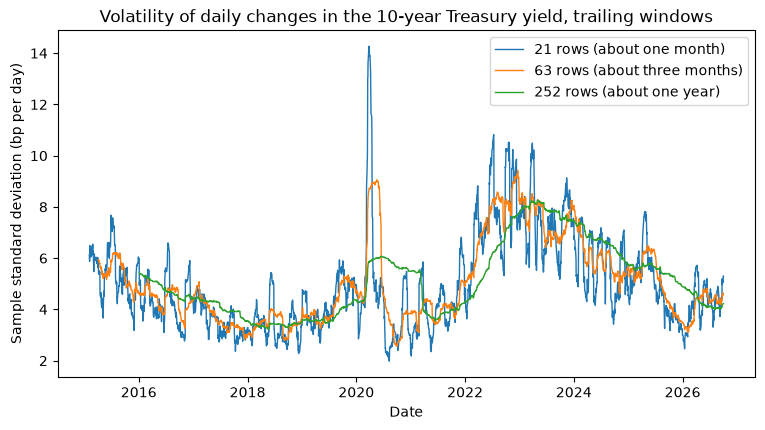

In [25]:
import matplotlib.pyplot as plt

# one series per window, every value in bp per day
vols = {window: md.rolling_vol_bp(ten_changes, window=window) for window in (21, 63, 252)}

fig, ax = plt.subplots(figsize=(9, 4.5))
for window, label in [(21, "about one month"), (63, "about three months"), (252, "about one year")]:
    ax.plot(vols[window].index, vols[window], label=f"{window} rows ({label})", linewidth=1)
ax.set_title("Volatility of daily changes in the 10-year Treasury yield, trailing windows")
ax.set_xlabel("Date")
ax.set_ylabel("Sample standard deviation (bp per day)")
ax.legend()
plt.show()

Q. For each window: when does it start, where does it end, and what were its highest and lowest values?

In [26]:
summary = pd.DataFrame({
    window: {
        "first value": vol.first_valid_index().date(),
        f"on {vol.index[-1].date()} (bp)": round(vol.iloc[-1], 2),
        "highest (bp)": round(vol.max(), 2),
        "highest on": vol.idxmax().date(),
        "lowest (bp)": round(vol.min(), 2),
        "lowest on": vol.idxmin().date(),
    }
    for window, vol in vols.items()
}).T.rename_axis("window (rows)")
summary

,first value,on 2026-10-02 (bp),highest (bp),highest on,lowest (bp),lowest on
window (rows),,,,,,
21,2015-02-03,5.29,14.27,2020-03-27,1.98,2020-08-10
63,2015-04-03,4.63,9.43,2022-12-20,2.57,2020-09-29
252,2016-01-05,4.22,8.26,2023-05-03,3.23,2018-05-21


* The 252-row line starts last, on 2016-01-05: it needs a year of changes before its first full window. The `NaN` at the start of each line is section 7.2's rule at work.
* The shorter the window, the more the line moves. Over the file the 21-row volatility ran from 1.98 bp on 2020-08-10 to 14.27 bp on 2020-03-27, a range of about 7 times. The 252-row volatility ran from 3.23 bp on 2018-05-21 to 8.26 bp on 2023-05-03, about 2.6 times. A long window averages a sharp month into a whole year.
* On 2026-10-02 the three stood at 5.29, 4.63, and 4.22 bp per day. Each says how much the 10-year yield moved over its own window. None of them says what happens next.

## Excel Side by Side

Every formula below was typed into Excel by script and filled down over the whole Treasury file, 2,940 rows (Excel 16.0 build 20430, 2026-10-04). The layout is the one the course's reference file uses: dates in A, the 2 Yr, 5 Yr, 10 Yr, and 30 Yr in B to E, and the 10 Yr's daily change in bp in F, `=(D3-D2)*100` from F3.

| Job | Python | Excel, written once and filled down | Largest gap from Python |
| --- | --- | --- | --- |
| 21-row volatility | `md.rolling_vol_bp(ten_changes, window=21)` | `=STDEV.S(F3:F23)` in G23 | 2.4e-14 bp |
| Population, beside it | `ten_changes.rolling(21).std(ddof=0)` | `=STDEV.P(F3:F23)` in H23 | 2.4e-14 bp |
| Annualised | `annualise=True` | `=G23*SQRT(252)` in I23 | 3.8e-13 bp |
| 63-row volatility | `window=63` | `=STDEV.S(F3:F65)` in J65 | 1.1e-14 bp |
| 252-row volatility | `window=252` | `=STDEV.S(F3:F254)` in K254 | 1.1e-14 bp |
| 63-row mean of the level | `ten.rolling(63, min_periods=63).mean()` | `=AVERAGE(D2:D64)` in L64 | 2.7e-15 percent |
| The same, with `OFFSET` | as above | `=AVERAGE(OFFSET(D64,-62,0,63,1))` in M64 | 2.7e-15 percent |
| 21-row volatility, with `OFFSET` | as above | `=STDEV.S(OFFSET(F23,-20,0,21,1))` in N23 | 2.4e-14 bp |
| Sample, one value | `rolling_vol_bp` refuses `window=1` | `=STDEV.S(A1)` | shows `#DIV/0!` |

**The window is the range.** In `=STDEV.S(F3:F23)` the range F3:F23 is the window: 21 cells ending on the formula's own row. Filling down moves both ends one row at a time, which is exactly a trailing window in rows. Where you put the first formula is `min_periods`: start in the first row with a full window, and the cells above stay empty, as pandas leaves `NaN`.

**`OFFSET` says the same thing another way.** `=AVERAGE(OFFSET(D64,-62,0,63,1))` reads: from D64, go 62 rows up and 0 columns across, then take 63 rows and 1 column. That is D2:D64 again. Both forms gave the same numbers.

**Sample and population sit side by side.** G and H differ by the factor sqrt(21 / 20) on every row, and I is G times `SQRT(252)`, with the convention visible in the cell. On 2026-10-02, the last row, Excel returned:

In [27]:
# Excel's last row, from the day's Excel check, beside Python's own numbers for the same date
excel_last = {"vol21_bp": 5.294651389216601, "vol21_population_bp": 5.167050676973533,
              "vol21_annual_bp": 84.04998512789868, "vol63_bp": 4.628823961301718, "vol252_bp": 4.222979359434287}
python_last = {"vol21_bp": vol21.iloc[-1], "vol21_population_bp": ten_changes.iloc[-21:].std(ddof=0),
               "vol21_annual_bp": vol21_annual.iloc[-1], "vol63_bp": vols[63].iloc[-1], "vol252_bp": vols[252].iloc[-1]}

comparison = pd.DataFrame({"Excel": excel_last, "Python": python_last})
comparison["gap"] = (comparison["Excel"] - comparison["Python"]).abs()
comparison

,Excel,Python,gap
vol21_bp,5.294651,5.294651,1.243450e-14
vol21_population_bp,5.167051,5.167051,8.881784e-16
vol21_annual_bp,84.049985,84.049985,1.989520e-13
vol63_bp,4.628824,4.628824,9.769963e-15
vol252_bp,4.222979,4.222979,7.993606e-15


* The same numbers to the last few binary digits: an `STDEV.S` column filled down and `rolling_vol_bp` are the same calculation, written two ways.

## Save the Day with Git

This morning's commit holds yesterday's `marketdata.py`. Commit today's, then use `git restore --source` to look at yesterday's version in the folder and come back.

Q. What changed today?

In [28]:
# both files modified; --stat counts the lines added to each
!git -C "{work}" status --short marketdata.py test_marketdata.py
!git -C "{work}" diff --stat

 M marketdata.py
 M test_marketdata.py


 marketdata.py      | 28 ++++++++++++++++++++++++++++
 test_marketdata.py | 48 ++++++++++++++++++++++++++++++++++++++++++++++++
 2 files changed, 76 insertions(+)


Q. Commit today's two files.

In [29]:
!git -C "{work}" add marketdata.py test_marketdata.py
!git -C "{work}" commit -q -m "Add rolling_vol_bp and the no-lookahead test helper" -m "Volatility is the sample standard deviation of daily changes in bp over a trailing window of rows."
!git -C "{work}" log --oneline

0d5eb75 Add rolling_vol_bp and the no-lookahead test helper
4b7818f Start of day 7: marketdata as it stood at the end of day 6


* Two commits: this morning's start, and today's work on top. `HEAD` is today's; `HEAD~1` is the one before it.

Q. Put yesterday's `marketdata.py` back in the folder, from the commit before the last one.

In [30]:
# --source names the commit to take the file from; the commits themselves do not change
!git -C "{work}" restore --source=HEAD~1 marketdata.py
!git -C "{work}" status --short marketdata.py

 M marketdata.py


In [31]:
# what is in the file on disk now?
text = (work / "marketdata.py").read_text(encoding="utf-8")
print(f"rolling_vol_bp in the file: {'def rolling_vol_bp' in text}; {len(text.splitlines())} lines")

rolling_vol_bp in the file: False; 389 lines


* `M`: the file differs from the last commit, because it now holds yesterday's version, without `rolling_vol_bp`. Nothing was deleted from Git: today's version is safe in `HEAD`. This is how you look at, or test against, an older file without undoing any commit.

Q. Come back to today's file.

In [32]:
# with no --source, restore takes the file from the last commit
!git -C "{work}" restore marketdata.py
!git -C "{work}" status --short marketdata.py

In [33]:
text = (work / "marketdata.py").read_text(encoding="utf-8")
print(f"rolling_vol_bp in the file: {'def rolling_vol_bp' in text}; {len(text.splitlines())} lines")

rolling_vol_bp in the file: True; 417 lines


* No status line: the file equals the last commit again. `git restore` with no `--source` throws away changes to the file since the last commit, so check `git status` before you run it on a file you have been editing.

## Bring It Home

Add today's function and tests to your own `my_bondmath` folder. Open a PowerShell terminal in VS Code, with the course's `.venv` active.

**Step 1.** Go to your folder and open the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
code marketdata.py
code test_marketdata.py
```

**Step 2.** Paste the code of section 7.3's `%%writefile -a marketdata.py` cell, without its first line, at the end of `marketdata.py`, and the code of section 7.6's `%%writefile -a test_marketdata.py` cell at the end of `test_marketdata.py`. Save both. The tests read `treasury_par_yields.csv` and `course3_excel_reference.csv` from the same folder; if either is missing, copy it from the `data` folder of the course repo.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_marketdata.py
```

The last line says `29 passed`.

**Step 4.** Read what changed, then commit.

```powershell
git diff --stat
git add marketdata.py test_marketdata.py
git commit -m "Add rolling_vol_bp and the no-lookahead test helper" -m "Volatility is the sample standard deviation of daily changes in bp over a trailing window of rows."
git log --oneline -3
```

**Step 5.** Try today's Git step on your own history: `git restore --source=HEAD~1 marketdata.py`, look at the file, then `git restore marketdata.py` to come back.

**In Colab**, download `marketdata.py` and `test_marketdata.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Say what a window in rows and a window in calendar days each hold, and why this course counts rows.
* Build a trailing, right-aligned window with `min_periods` equal to the window, and explain the `NaN` at the start.
* Compute volatility as the sample standard deviation of daily changes in bp with `rolling_vol_bp`, matched to Excel's `STDEV.S` filled down.
* Tell the sample from the population standard deviation in pandas, NumPy, and Excel.
* Annualise by sqrt(252) as a labelled convention, never silently.
* Prove a window function uses no future data with `assert_no_lookahead`.
* Look at yesterday's version of a file with `git restore --source=HEAD~1` and come back.

Tomorrow, day 8, asks where today's value sits in its own history: the z-score and the percentile rank, over the same kind of trailing window, each with its own no-lookahead test.

## Exercises

The exercises use the 5-year yield and the synthetic high yield spread. The spreads are invented for this course: they are not ICE, Moody's, or any index. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the data, imports the no-lookahead helper, and defines `check`, a small function that marks your answers.

In [34]:
# the Treasury file in percent, the synthetic spreads in bp, and the 10-year daily changes in bp
curve = pd.read_csv("treasury_par_yields.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")
spreads = pd.read_csv("course3_synthetic_spreads.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")
ten_changes = md.change_bp(curve["10 Yr"]).dropna()

# the helper and cut dates from today's tests
from test_marketdata import assert_no_lookahead, CUT_DATES


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Compute the 21-row volatility of the 5-year yield's daily changes and of the synthetic high yield spread's daily changes (column `hy_spread_bp`, already in bp, so `percent_units=False`). Store each one's value on 2026-10-02, in bp per day, in **ex1_five_year_bp** and **ex1_high_yield_bp**.

In [35]:
ex1_five_year_bp = ...
ex1_high_yield_bp = ...

In [36]:
check("Exercise 1 the 5 Yr", ex1_five_year_bp, 6.030083313015232)
check("Exercise 1 the high yield spread", ex1_high_yield_bp, 5.4347471137557255)

Exercise 1 the 5 Yr: not attempted yet
Exercise 1 the high yield spread: not attempted yet


### Exercise 2

Q. For each calendar year in the file, on which date was the 63-row volatility of the 5-year yield's daily changes at its highest? Store a dictionary of year (an integer) to date (ISO text, `"YYYY-MM-DD"`) in **ex2_dates**. Drop the `NaN` at the start before you look for the highest value.

In [37]:
ex2_dates = ...

In [38]:
check("Exercise 2 the dates of the highest 63-row volatility", ex2_dates, {2015: '2015-04-06', 2016: '2016-08-12', 2017: '2017-02-09', 2018: '2018-06-14', 2019: '2019-10-30', 2020: '2020-04-27', 2021: '2021-12-16', 2022: '2022-08-08', 2023: '2023-06-02', 2024: '2024-01-02', 2025: '2025-05-12', 2026: '2026-05-26'})

Exercise 2 the dates of the highest 63-row volatility: not attempted yet


### Exercise 3

Q. Add a function to your module. `vol_ratio(short_vol, long_vol)` returns the short-window volatility divided by the long-window volatility, date by date, and raises `ValueError` if the two series do not have the same dates. Write the docstring first, with the units. Then add `test_vol_ratio_hand_values`, which checks a `NaN`, two hand values, and the `ValueError`. Run pytest, reload the module, and store the ratio of the 5-year yield's 21-row volatility to its 252-row volatility on 2026-10-02 in **ex3_ratio**.

Write the function in the cell that starts with `%%writefile -a marketdata.py` and the test in the one that starts with `%%writefile -a test_marketdata.py`, and run each of those cells once.

In [39]:
%%writefile -a marketdata.py


# Exercise 3: write vol_ratio(short_vol, long_vol) below this line

Appending to marketdata.py


In [40]:
%%writefile -a test_marketdata.py


# Exercise 3: write test_vol_ratio_hand_values() below this line

Appending to test_marketdata.py


In [41]:
# run pytest, reload the module, then call your function
ex3_ratio = ...

In [42]:
check("Exercise 3 the volatility ratio", ex3_ratio, 1.2733566476405627)

Exercise 3 the volatility ratio: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a trailing volatility function for a daily table, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Volatility of daily changes in bp over a trailing window, for the desk's daily market table.

    Units: changes in bp in, bp per day out. Convention: the window ending on date t holds t and the
    window - 1 rows before it; full windows only; sample standard deviation (Excel STDEV.S). It uses no
    data after t: the value on any date is the same whether the series stops there or runs on.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns numbers of the right size, and contains one bug.

In [43]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def trailing_vol_bp(changes_bp, window=63):
    """Volatility of daily changes in bp over a trailing window, for the desk's daily market table.

    Units: changes in bp in, bp per day out. Convention: the window ending on date t holds t and the
    window - 1 rows before it; full windows only; sample standard deviation (Excel STDEV.S). It uses no
    data after t: the value on any date is the same whether the series stops there or runs on.
    """
    # a window of `window` rows, full windows only, sample standard deviation
    return changes_bp.rolling(window, min_periods=window, center=True).std()

Q. Before you run the next cell: will the value on 2026-06-30 be the same from the full series and from the series cut at 2026-06-30? The docstring says it must be.

In [44]:
full = trailing_vol_bp(ten_changes)
cut = trailing_vol_bp(ten_changes.loc[:"2026-06-30"])
print(f"from the full series:        {full.loc['2026-06-30']:.4f} bp")
print(f"from the series cut there:   {cut.loc['2026-06-30']:.4f} bp")

from the full series:        4.5551 bp
from the series cut there:   nan bp


Q. Test the function against its docstring before you trust it.

In [45]:
# the test, written from the docstring before the code is trusted: no future data.
# It is assert_no_lookahead's loop, written out so the message names the date that fails.
full = trailing_vol_bp(ten_changes)
for cut in CUT_DATES:
    cut_run = trailing_vol_bp(ten_changes.loc[:cut])
    assert full.loc[:cut].equals(cut_run), f"up to {cut} the values change when later rows are added"
print("trailing_vol_bp uses no future data on any cut date")

AssertionError: up to 2025-04-17 the values change when later rows are added

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store `trailing_vol_bp(ten_changes).iloc[-1]`, the fixed function's value on the file's last date, in **ex4_last_bp**.

In [46]:
# fix the function above and run the test again, then store the answer
ex4_last_bp = ...

In [47]:
check("Exercise 4 the fixed function on the last date", ex4_last_bp, 4.628823961301708)

Exercise 4 the fixed function on the last date: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```